## 我的说明

1. 方法对data2效果不佳, 对data1是相对准确的
2. 这种方法是对PCA的概率学解释版本---生成模型.与一般的PCA相比,他是基于模型的(高斯分布). 因此他对数据有假设,首先假设数据集是服从高斯分布的. 其二假设低维变量也是符合高斯分布的.
3. 方法有两个部分, 一是利用最大似然估计,估计出参数. 二是在训练集中使用用训练集拟合出的模型对样本求负对数似然,数值越大, 则它由模型生成的概率越低, 越可能是异常点.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
train_data = pd.read_csv('test\Train_data.csv')
test_data1 = pd.read_csv('test\Test_data1.csv')
test_data2 = pd.read_csv('test\Test_data2.csv')
print(f"{train_data.shape} {test_data1.shape} {test_data2.shape}")

(3999, 31) (3999, 31) (3999, 31)


#### 数据预处理

+ 对train_data进行标准化
+ 同样的参数应用到test_data

In [4]:
from sklearn.preprocessing import StandardScaler

# 训练集标准化
scaler = StandardScaler()
standard_train_data = scaler.fit_transform(train_data)  # 计算均值、标准差
standard_test_data1 = scaler.transform(test_data1)       # 使用训练集的均值、标准差
standard_test_data2 = scaler.transform(test_data2)

#### PPCA

**重要的假设**:
+ 潜在变量$z$服从标准高斯分布
+ $x|z$ 是多元高斯分布---训练数据符合这一特征
---

**PPCA（Probabilistic Principal Component Analysis）** 是一种基于概率模型的降维方法，为传统PCA提供了统计学的解释框架。其核心思想是通过引入潜在变量，将高维数据的生成过程建模为低维潜在变量经过线性变换并添加噪声的结果。

---

## 基本原理

### 1. **生成模型**
PPCA假设观测数据由低维潜在变量生成，具体形式为：  
$$
\mathbf{x} = \mathbf{W}\mathbf{z} + \boldsymbol{\mu} + \boldsymbol{\epsilon}
$$  
- $\mathbf{z} \in \mathbb{R}^d$：潜在变量（$d \ll D$），服从标准高斯分布 $\mathbf{z} \sim \mathcal{N}(0, \mathbf{I}_d)$。  
- $\mathbf{W} \in \mathbb{R}^{D \times d}$：线性变换矩阵，将低维空间映射到高维空间。  
- $\boldsymbol{\mu} \in \mathbb{R}^D$：数据均值。  
- $\boldsymbol{\epsilon} \sim \mathcal{N}(0, \sigma^2 \mathbf{I}_D)$：各向同性高斯噪声，方差为$\sigma^2$。

### 2. **边缘分布**
通过积分边缘化潜在变量$\mathbf{z}$，观测数据$\mathbf{x}$的边缘分布为：  
$$
\mathbf{x} \sim \mathcal{N}\left(\boldsymbol{\mu}, \mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}_D\right)
$$  
协方差矩阵由两部分组成：  
- $\mathbf{W}\mathbf{W}^\top$：低维子空间的结构。  
- $\sigma^2 \mathbf{I}_D$：噪声引起的球形协方差。

---

## 数学思想与推导

### 1. **最大似然估计**
目标是通过最大化观测数据的对数似然函数估计参数$\mathbf{W}$和$\sigma^2$。假设数据已中心化（$\boldsymbol{\mu}=0$），对数似然为：  
$$
\mathcal{L} = -\frac{N}{2} \left[ D \ln(2\pi) + \ln|\mathbf{C}| + \text{tr}(\mathbf{C}^{-1} \mathbf{S}) \right]
$$  
其中：
- $\mathbf{C} = \mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}_D$，  
- $\mathbf{S} = \frac{1}{N} \sum_{i=1}^N \mathbf{x}_i \mathbf{x}_i^\top$为样本协方差矩阵。

### 2. **解析解**
- **主成分方向**：$\mathbf{W}$的极大似然估计与样本协方差矩阵$\mathbf{S}$的前$d$个特征向量$\mathbf{U}_d$相关：  
  $$
  \mathbf{W} = \mathbf{U}_d (\boldsymbol{\Lambda}_d - \sigma^2 \mathbf{I}_d)^{1/2} \mathbf{R}
  $$  
  其中：
  - $\boldsymbol{\Lambda}_d$为前$d$个特征值组成的对角矩阵，  
  - $\mathbf{R}$为任意正交矩阵（通常取$\mathbf{R}=\mathbf{I}$）。  

- **噪声方差**：  
  $$
  \sigma^2 = \frac{1}{D-d} \sum_{i=d+1}^D \lambda_i
  $$  
  即未被选中的特征值的平均值。

### 3. **与传统PCA的联系**
- 当$\sigma^2 \to 0$时，PPCA退化为传统PCA，数据完全位于主成分张成的子空间。  
- 当$\sigma^2 > 0$时，PPCA允许数据在主成分周围存在高斯噪声，提供了更灵活的概率解释。

---


In [5]:
n_samples, n_features = standard_train_data.shape
# 样本协方差矩阵
S = (standard_train_data.T @ standard_train_data) / n_samples
# 对样本进行特征分解
def ppca_fit(S,d=10):
    """ 对S矩阵进行特征分解, 提取前d个特征 """
    eigenvalues, eigenvectors = np.linalg.eigh(S) #默认是升序排列的
    #print(eigenvalues[::-1])
    #print(eigenvectors[:,::-1])
    eigenvalues = eigenvalues[::-1]
    eigenvectors = eigenvectors[:,::-1]
    sigma_sq = np.mean(eigenvalues[d:])
    print(sigma_sq)
    lambda_d = np.diag(eigenvalues[:d] - sigma_sq)
    U_d = eigenvectors[:, :d]
    W = U_d @ np.sqrt(lambda_d)
    #print(W)
    return W,sigma_sq,eigenvectors, eigenvalues
# 超参数, 降到多少维
d = 10
W, sigma_sq, U_d, eigenvalues = ppca_fit(S, d)
print(f"噪声方差σ² = {sigma_sq:.4f}")

0.5581589959259814
噪声方差σ² = 0.5582


#### 异常检测:

**核心思想**:
PPCA假设正常数据服从一个由​**低维潜在变量**和 **高斯噪声**​共同生成的高斯分布。异常检测的目标是：​找到偏离该分布的样本，即在该分布下概率密度极低的点。

+ ​关键假设：正常数据集中分布在由主成分（W）张成的低维子空间附近，并受到方差为 $σ^2$的高斯噪声干扰。
+ ​异常定义：若某个测试样本的生成概率显著低于正常数据，则判定为异常。


### **2.1 观测数据的高斯分布**

根据PPCA模型，观测数据 $\mathbf{x} \in \mathbb{R}^D$ 服从高斯分布：
$$
\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \mathbf{C}), \quad \mathbf{C} = \mathbf{W}\mathbf{W}^\top + \sigma^2 \mathbf{I}_D
$$
其中：
- $\boldsymbol{\mu}$：训练集均值。
- $\mathbf{C}$：协方差矩阵，由主成分方向 $\mathbf{W}$ 和噪声方差 $\sigma^2$ 共同决定。

### **2.2 概率密度函数（PDF）**

单个样本 $\mathbf{x}$ 的概率密度为：
$$
p(\mathbf{x}) = \frac{1}{(2\pi)^{D/2} |\mathbf{C}|^{1/2}} \exp\left( -\frac{1}{2} (\mathbf{x}-\boldsymbol{\mu})^\top \mathbf{C}^{-1} (\mathbf{x}-\boldsymbol{\mu}) \right)
$$

### **2.3 负对数似然（NLL）作为异常分数**

- **定义**：负对数似然（Negative Log-Likelihood, NLL）为：
  $$
  \text{NLL}(\mathbf{x}) = -\ln p(\mathbf{x}) = \frac{1}{2} \left[ D\ln(2\pi) + \ln|\mathbf{C}| + (\mathbf{x}-\boldsymbol{\mu})^\top \mathbf{C}^{-1} (\mathbf{x}-\boldsymbol{\mu}) \right]
  $$
- **物理意义**：
  - NLL越小，样本越可能属于正常数据分布。
  - NLL越大，样本越偏离正常分布，越可能是异常。


## **3. 直观解释**

### **3.1 马氏距离（Mahalanobis Distance）**

$$
\text{MD}(\mathbf{x}) = \sqrt{(\mathbf{x}-\boldsymbol{\mu})^\top \mathbf{C}^{-1} (\mathbf{x}-\boldsymbol{\mu})}
$$
- **意义**：衡量样本与分布中心的距离，考虑了协方差矩阵的几何结构（即数据各维度的相关性和尺度）。
- **对比欧氏距离**：
  - 欧氏距离假设各维度独立且尺度相同，而马氏距离通过 $\mathbf{C}^{-1}$ 自动调整。

### **3.2 为什么NLL能检测异常？**

1. **协方差矩阵 $\mathbf{C}$ 的作用**：
   - $\mathbf{W}\mathbf{W}^\top$ 捕捉了数据在低维子空间的结构。
   - $\sigma^2 \mathbf{I}$ 允许数据在主成分方向周围存在噪声。
   - 异常点要么偏离主成分子空间，要么噪声显著超出正常范围。

2. **NLL的分解**：
   - **$\ln|\mathbf{C}|$**：协方差矩阵的行列式反映数据分布的“体积”。
   - **马氏距离项**：直接衡量样本与分布中心的偏离程度。

---

In [6]:
def compute_nll(x_test,W,sigma_sq):
    """
    计算x_test的对数似然
    """
    D = W.shape[0]
    
    C = W @ W.T + sigma_sq * np.eye(D)

    inv_C = np.linalg.inv(C)
    log_det_C = np.log(np.linalg.det(C))
    
    #计算马氏距离的平方项
    mahalanobis_term = x_test.T @ inv_C @ x_test

    nll = 0.5 * (D * np.log(2*np.pi) + log_det_C + mahalanobis_term)

    return nll

test_scores1 = [compute_nll(x,W,sigma_sq) for x in standard_test_data1]

train_scores = [compute_nll(x,W,sigma_sq) for x in standard_train_data]




In [13]:
threshold = np.percentile(train_scores,99)
test_anomalies1 = test_data1[test_scores1 > threshold]
test1_idx = test_data1.index[test_scores1 > threshold]
print(f"异常样本数：{len(test_anomalies1)}")
print(f"异常索引:{test1_idx[:100]}")
print(threshold)

test_scores2 = [compute_nll(x,W,sigma_sq) for x in standard_test_data2]
test_anomalies2 = test_data2[test_scores2 > threshold]
test2_idx = test_data2.index[test_scores2 > threshold]
print(f"异常样本数：{len(test_anomalies2)}")
print(f"异常索引:{test2_idx[:int(0.5*len(test_anomalies2))]}")


异常样本数：2017
异常索引:Index([ 268,  411,  438,  511,  529,  585,  618,  944,  947,  963,  977, 1028,
       1045, 1102, 1401, 1412, 1802, 1925, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029,
       2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041,
       2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053,
       2054, 2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065,
       2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077,
       2078, 2079, 2080, 2081],
      dtype='int64')
52.21148536613459
异常样本数：68
异常索引:Index([ 268,  411,  438,  511,  529,  585,  618,  944,  947,  963,  977, 1028,
       1045, 1102, 1401, 1412, 1802, 1925, 2024, 2075, 2101, 2103, 2110, 2156,
       2162, 2166, 2193, 2196, 2210, 2280, 2390, 2420, 2469, 2541],
      dtype='int64')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(tn, fp, fn, tp, title='Confusion Matrix'):
    # 重构混淆矩阵为二维数组
    cm = np.array([[tn, fp],
                   [fn, tp]])
    
    # 绘制热力图
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Anomaly"],yticklabels=["Normal", "Anomaly"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

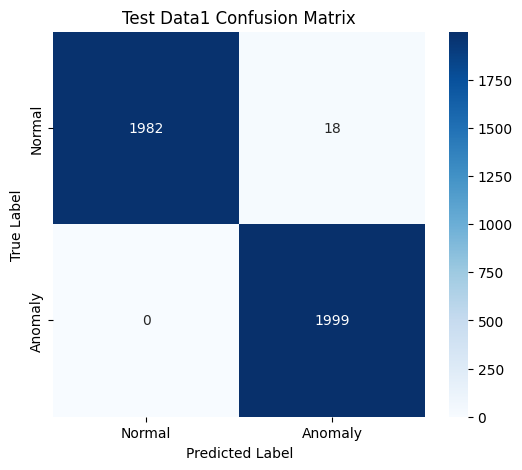

1982 18 0 1999


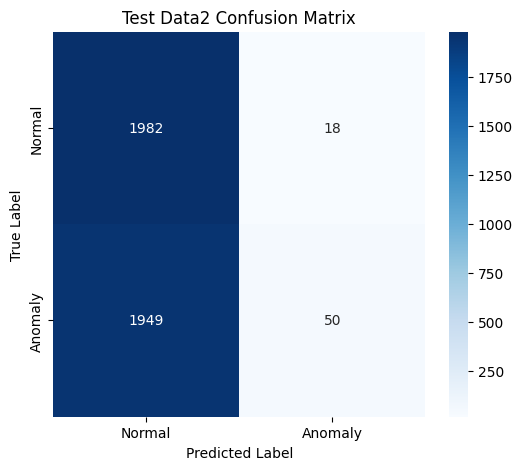

检测率1（Recall）: 100.00%
误报率1（FPR）: 0.90%
检测率2（Recall）: 2.50%
误报率2（FPR）: 0.90%


In [ ]:
from sklearn.metrics import confusion_matrix

def check_recall_fpr(test_data, test_scores, threshold, ano_start, ano_end):
    # 生成真实标签（基于索引）
    y_true = (test_data.index >= ano_start) & (test_data.index < ano_end)
    y_true = y_true.astype(int)  # 0表示正常，1表示异常
    
    # 生成预测标签
    y_pred = (test_scores > threshold).astype(int)
    
    # 计算混淆矩阵
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # 计算检测率和误报率
    detection_rate = tp / (tp + fn)
    false_alarm_rate = fp / (fp + tn)
    
    return tn, fp, fn, tp, detection_rate, false_alarm_rate  # 返回所有元素

# 对 test_data1 计算混淆矩阵并可视化
tn1, fp1, fn1, tp1, detection_rate1, false_alarm_rate1 = check_recall_fpr(test_data1, test_scores1, threshold, 2000, 4000)
plot_confusion_matrix(tn1, fp1, fn1, tp1, title='Test Data1 Confusion Matrix')

# 对 test_data2 计算混淆矩阵并可视化
tn2, fp2, fn2, tp2, detection_rate2, false_alarm_rate2 = check_recall_fpr(test_data2, test_scores2, threshold, 2000, 4000)
plot_confusion_matrix(tn2, fp2, fn2, tp2, title='Test Data2 Confusion Matrix')

# 打印指标
print(f"检测率1（Recall）: {detection_rate1:.2%}")
print(f"误报率1（FPR）: {false_alarm_rate1:.2%}")
print(f"检测率2（Recall）: {detection_rate2:.2%}")
print(f"误报率2（FPR）: {false_alarm_rate2:.2%}")

### 可视化

图片横轴是样本序号, 纵轴是对数似然的值, 值越大, 样本点异常的概率越大

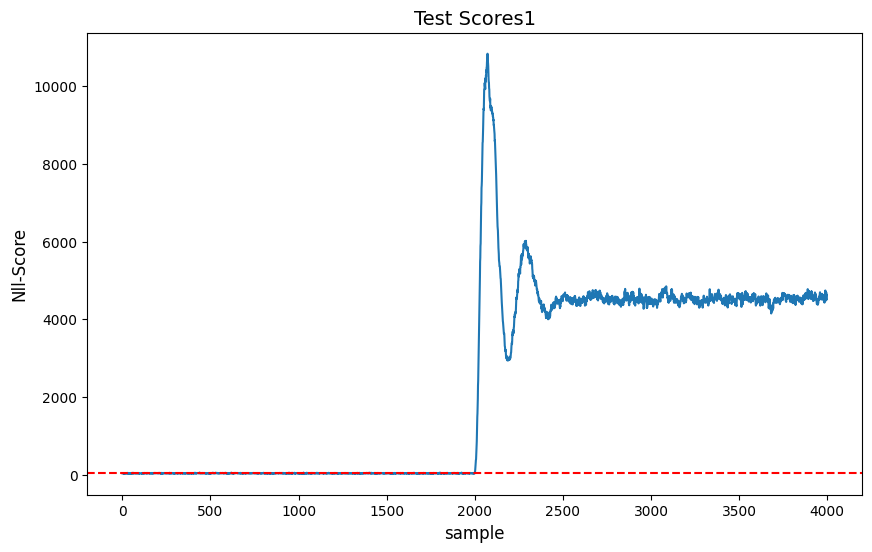

In [19]:
x = np.arange(0,len(test_scores1))
plt.figure(figsize=(10,6))
plt.plot(x,test_scores1,label='Test Scores1')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold})')
plt.title('Test Scores1', fontsize=14)
plt.xlabel('sample', fontsize=12)
plt.ylabel('Nll-Score', fontsize=12)
plt.show()

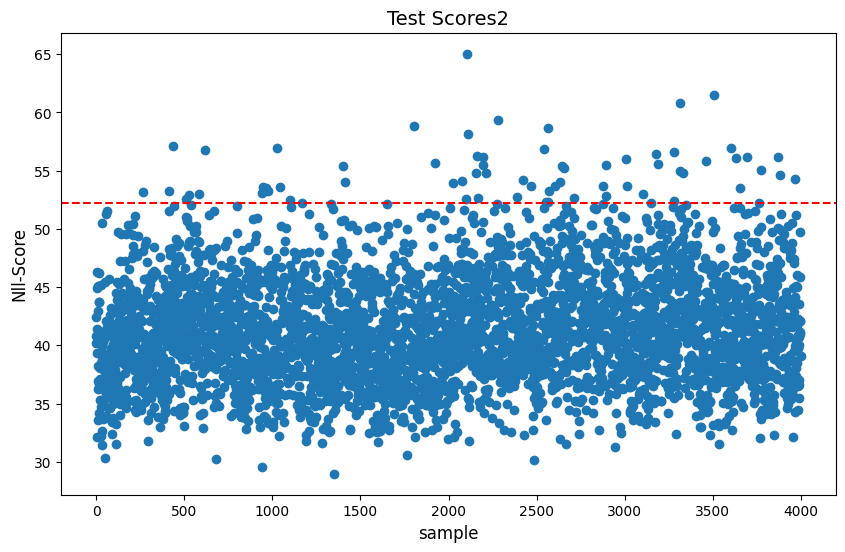

In [20]:
x = np.arange(0,len(test_scores1))
plt.figure(figsize=(10,6))
plt.scatter(x,test_scores2,label='Test Scores2')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({threshold})')
plt.title('Test Scores2', fontsize=14)
plt.xlabel('sample', fontsize=12)
plt.ylabel('Nll-Score', fontsize=12)
plt.show()